In [1]:
# !pip install scipy

In [2]:

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import scipy
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal

# Paths
DATA_PROCESSED = Path(r'C:\dev\clinicaltrials-study\data\processed')
RESULTS_DIR = Path("../results/EDA2_outputs")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Utility: safe save figure
def savefig(filename, tight=True, dpi=200, show=True):
    if tight:
        plt.tight_layout()
    filepath = RESULTS_DIR / filename
    plt.savefig(filepath, dpi=dpi)
    if show:
        plt.show()
    plt.close()

In [3]:
# === Helper Function 1: Chi-Square Analysis ===
def chi2_analysis(df, cols, target_col='overall_status', filename=None):
    """
    Perform chi-square tests for categorical and flag columns against a target column.
    범주형 열과 플래그 열에 대해 대상 열과 카이제곱 검정 수행
    Saves summary as <filename> in RESULTS_DIR.
    요약은 <filename> 에 저장됨
    Returns:
        - results_df: summary dataframe (Chi², p-value, Cramér's V)
        - 카이제곱검정: 임상단계와 성공여부는 아무 상관이 없다는 가정
        - p-value: 우연히 이런 결과가 나올 확율 여부 판단 (0.05미만이면 유의미)
        - 크래머브이: 카이제곱 값은 데이터 개수가 많아지면 커지는 단점이 있음. 이를 보완해서 0~1 사이의 점수로
                     상관관계의 '강도'를 나타낸 지표. 1에 가까울수록 아주 강력한 연관이 있음을 의미
        - expected_dict: dict of expected frequency tables for each feature
        - 기대빈도 저장: 만약 두 변수가 아무상관이 없다면 이론적으로 나와야 하는 수치를 따로 보관하여 실제 값과 비교하기 위함.
    """
    results, expected_dict = [], {}

    for col in cols:
        contingency = pd.crosstab(df[col], df[target_col])   # 교차표 생성
        contingency.columns = ['Failure', 'Success']

        chi2_val, p, dof, expected = chi2_contingency(contingency, correction=False) # 카이제곱검정
        n = contingency.sum().sum()
        r, c = contingency.shape
        cramers_v = np.sqrt((chi2_val / n) / min(r - 1, c - 1))

        results.append({
            'Feature': col,
            'Chi2': round(chi2_val, 2),
            'p_value': round(p, 4),
            'Cramers_v': round(cramers_v, 3)
        })

        expected_dict[col] = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

    results_df = pd.DataFrame(results)
    results_df.to_csv(RESULTS_DIR / filename, index=False)
    print("Chi-square summary:")
    display(results_df)

    return results_df, expected_dict

In [4]:
# === Helper Function 2: Categorical Feature Stats ===
def categorical_feature_stats(df, col, expected_dict, target_col='overall_status',
                              xlabel=None, title=None, figsize=(12, 6),
                              rotate_ticks=False, show=False):
    """
    Generate detailed summary + plots for a categorical feature vs target.
    범주형 특성과 목표 변수 간의 관계에 대한 상세 요약 및 그래프를 생성합니다.
    Saves:
    - {col}_summary.csv → RESULTS_DIR
    - {col}_residuals.png → RESULTS_DIR
    - {col}_barplot.png → RESULTS_DIR
    """
    # Contingency table  우연성 테이블
    contingency = pd.crosstab(df[col], df[target_col])
    contingency.columns = ['Failure', 'Success']
    contingency['Total'] = contingency.sum(axis=1)
    contingency['Success_rate'] = (contingency['Success'] / contingency['Total'] * 100).round(2)
    contingency['Failure_rate'] = (contingency['Failure'] / contingency['Total'] * 100).round(2)

    # Residuals  잔차분석: 통계적으로 기대했던 값보다 실제값이 얼마나 더 많이(또는 적게) 나왔는가 계산
    expected_df = expected_dict[col].round(2)
    residuals = ((contingency[['Failure', 'Success']] - expected_df) / np.sqrt(expected_df)).round(2)
    expected_df.columns = ['Expected_Failure', 'Expected_Success']
    residuals.columns = ['Residual_Failure', 'Residual_Success']

    # Summary table
    summary = pd.concat(
        [contingency.reset_index(), expected_df.reset_index(drop=True), residuals.reset_index(drop=True)],
        axis=1
    )
    table_path = RESULTS_DIR / f"{col}_vs_{target_col}_summary.csv"
    summary.to_csv(table_path, index=False)
    if show:
        print(f"{col}_vs_{target_col}_summary:")
        display(summary)

    # Residual heatmap  잔차 히트맵
    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(residuals, annot=True, cmap="coolwarm", center=0)
    ax.set_ylabel(col, fontsize=12, fontweight='bold')
    plt.title(f"Chi² Residuals: {col} vs {target_col}", fontsize=14, fontweight='bold')
    plt.yticks(rotation=0)
    savefig(f"{col}_residuals.png", show=show)

    # Barplot
    melted = summary.melt(id_vars=col,
                          value_vars=['Success', 'Failure'],
                          var_name='Outcome',
                          value_name='Count')

    plt.figure(figsize=figsize)
    ax = sns.barplot(data=melted, x=col, y='Count', hue='Outcome',
                     palette={'Failure': 'salmon', 'Success': 'skyblue'})

    if rotate_ticks:
        plt.xticks(rotation=45, ha='right')

    # Annotate each bar with percentage
    for i, p in enumerate(ax.patches):
        count = int(p.get_height())
        if count == 0:
            continue
        category_name = melted.iloc[i][col]
        category_total = summary.loc[summary[col] == category_name, 'Total'].values[0]
        pct = 100 * count / category_total
        ax.annotate(f'{pct:.1f}%',
                    (p.get_x() + p.get_width() / 2, count + max(category_total * 0.01, 50)),
                    ha='center', va='bottom', fontsize=9)

    plt.title(title if title else f"Distribution of {col} vs {target_col}", fontsize=14, fontweight='bold')
    plt.xlabel(xlabel if xlabel else col, fontsize=12, fontweight='bold')
    plt.ylabel('Number of Trials', fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    savefig(f"{col}_vs_{target_col}_barplot.png", show=show)


In [5]:
# === Helper Function 3: Flag/Ternary Columns ===
def plot_flag_columns(df, flag_col, target_col='overall_status', show=False):
    """
    Plot barplot of ternary/binary flag column vs target.
    삼진/이진 플래그 열과 목표값 간의 관계를 막대 그래프로 나타냅니다.
    Saves one plot per flag column into RESULTS_DIR.
    """
    hue_order = sorted(df[target_col].unique())

    plt.figure(figsize=(8, 6))
    ax = sns.countplot(
        data=df, x=flag_col, hue=target_col,
        hue_order=hue_order,
        palette={0: 'salmon', 1: 'skyblue'}
    )
    ax.set_title(f"{flag_col} vs {target_col}", fontsize=12, fontweight='bold')
    ax.set_xlabel(flag_col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Number of Trials', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    # Annotate percentages
    # get the two Bar Containers (one per hue)
    bars_fail, bars_succ = ax.containers[:2]

    for k in range(len(bars_fail.patches)):
        b0 = bars_fail.patches[k]   
        b1 = bars_succ.patches[k]   
        h0 = b0.get_height()
        h1 = b1.get_height()
        total = h0 + h1
        if total == 0:
            continue
        p0 = 100 * h0 / total
        p1 = 100 * h1 / total

        ax.annotate(f'{p0:.1f}%', 
                    (b0.get_x() + b0.get_width()/2, h0 + 1000),
                    ha = 'center', va = 'bottom', fontsize = 9)
        ax.annotate(f'{p1:.1f}%', 
                    (b1.get_x() + b1.get_width()/2, h1 + 1000),
                    ha = 'center', va = 'bottom', fontsize = 9)

    savefig(f"{flag_col}_vs_{target_col}.png", show=show)

In [6]:
# Load dataset
df_EDA_2 = pd.read_csv(DATA_PROCESSED / "df_EDA_1.csv")

print("Shape:", df_EDA_2.shape)

Shape: (278762, 82)


In [7]:
# Converts one-hot encoded columns with a shared prefix into a single categorical column
# 공통 접두사를 가진 원핫 인코딩된 열을 단일 범주형 열로 변환
def merge_onehot_prefix(df, new_col, prefix, exclude = None):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if exclude:
        cols = [c for c in cols if c not in exclude]
    
    df[cols] = df[cols].fillna(0).astype(float)
    df[new_col] = df[cols].idxmax(axis = 1).str.replace(prefix, "", regex = False)

    # if all the values are zeros in a row, set as 'None'
    df.loc[df[cols].sum(axis = 1) == 0, new_col] = "None"

    # if more than 1, mark as 'Multiple'
    # 중복일 경우 "multiple"로 명시
    df.loc[df[cols].sum(axis = 1) > 1, new_col] = "Multiple"

In [8]:
# Apply transformation to various one-hot groups
merge_onehot_prefix(df_EDA_2, new_col = 'phase_grouped', prefix = 'phase_')
merge_onehot_prefix(df_EDA_2, new_col = 'intervention_grouped', prefix = 'intervention_', exclude = ['intervention_count'])
merge_onehot_prefix(df_EDA_2, new_col = 'condt_grouped', prefix = 'condt_')
merge_onehot_prefix(df_EDA_2, new_col = 'allocation_grouped', prefix = 'allocation_')
merge_onehot_prefix(df_EDA_2, new_col = 'masking_grouped', prefix = 'masking_')
merge_onehot_prefix(df_EDA_2, new_col = 'model_grouped', prefix = 'model_')
merge_onehot_prefix(df_EDA_2, new_col = 'purpose_grouped', prefix = 'purpose_')
merge_onehot_prefix(df_EDA_2, new_col = 'sponsor_grouped', prefix = 'sponsor_')
merge_onehot_prefix(df_EDA_2, new_col = 'elig_gender_grouped', prefix = 'elig_gender_')
merge_onehot_prefix(df_EDA_2, new_col = 'elig_age_grouped', prefix = 'elig_age_')

In [9]:
print(df_EDA_2.columns.tolist())

['nct_id', 'enrollment', 'overall_status', 'number_of_arms', 'has_dmc', 'has_expanded_access', 'is_fda_regulated_drug', 'is_fda_regulated_device', 'duration_of_study', 'phase_1', 'phase_2', 'phase_3', 'phase_4', 'phase_unknown', 'intervention_behavioral', 'intervention_biological', 'intervention_combination_product', 'intervention_device', 'intervention_diagnostic_test', 'intervention_dietary_supplement', 'intervention_drug', 'intervention_genetic', 'intervention_other', 'intervention_procedure', 'intervention_radiation', 'intervention_count', 'has_multiple_intervention_types', 'condt_cancers', 'condt_cardiovascular_diseases', 'condt_dental_disorders', 'condt_dermatological_disorders', 'condt_endocrine/metabolic_disorders', 'condt_gastrointestinal_disorders', 'condt_genetic_disorders', 'condt_infectious_diseases', 'condt_mental_disorders', 'condt_musculoskeletal_disorders', 'condt_neurodevelopmental_disorders', 'condt_opthamological_disorders', 'condt_others', 'condt_pain_disorders', '

In [10]:
# Analyze enrollment distribution and flag high-enrollment outliers by trial phase
# 임상시험 단계별 등록 분포를 분석하고 등록률이 높은 이상치를 표시
# Define phase one-hot encoded columns
phase_cols = ['phase_1', 'phase_2', 'phase_3', 'phase_4', 'phase_unknown']

# 백분위 기준점 : 97.5%지점(상위2.5%에 해당. 일반적인 이상치 경계), 99% 지점(상위1%값, 매우 이례적인 대규모 임상)
cutoff_975, cutoff_99, phase_enroll_summary = {}, {}, []

# Calculate thresholds and summary stats for each phase
for col in phase_cols:
    phase_data = df_EDA_2.loc[df_EDA_2[col] == 1, 'enrollment']

    # Percentile cutoffs
    cutoff_975[col] = phase_data.quantile(0.975)
    cutoff_99[col] = phase_data.quantile(0.99)

    # Counts above thresholds
    above_975 = (phase_data > cutoff_975[col]).sum()
    above_99 = (phase_data > cutoff_99[col]).sum()

    # Append to summary
    phase_enroll_summary.append({
        'Phase': col,
        'Total_count': phase_data.shape[0],
        '97.5 percentile': round(cutoff_975[col], 2),
        'count > 97.5': above_975,
        '99 percentile': round(cutoff_99[col], 2),
        'count > 99': above_99
    })

# Create summary DataFrame and save the table
phase_enroll_summary_df = pd.DataFrame(phase_enroll_summary)
display(phase_enroll_summary_df)
phase_enroll_summary_df.to_csv(DATA_PROCESSED / "df_phase_enroll_summary.csv")

# Add flags for high enrollment trials
df_EDA_2['high_enroll_flag_975'] = 0
df_EDA_2['high_enroll_flag_99'] = 0

for col in phase_cols:
    df_EDA_2.loc[(df_EDA_2[col] == 1) & (df_EDA_2['enrollment'] > cutoff_975[col]), 'high_enroll_flag_975'] = 1
    df_EDA_2.loc[(df_EDA_2[col] == 1) & (df_EDA_2['enrollment'] > cutoff_99[col]), 'high_enroll_flag_99'] = 1

# Print counts of flagged trials
print("Total trials flagged above 97.5 percentile:", df_EDA_2['high_enroll_flag_975'].sum())
print("Total trials flagged above 99 percentile:", df_EDA_2['high_enroll_flag_99'].sum())

,Phase,Total_count,97.5 percentile,count > 97.5,99 percentile,count > 99
0,phase_1,47402,216.97,1186,386.99,475
1,phase_2,43721,491.00,1093,800.00,437
2,phase_3,30057,3200.00,749,7507.96,301
3,phase_4,23784,1500.00,584,4045.14,238
4,phase_unknown,133798,1500.00,3297,4620.06,1338


Total trials flagged above 97.5 percentile: 6909
Total trials flagged above 99 percentile: 2789


In [11]:
# Define categorical features
cat_cols = [
    'phase_grouped', 'intervention_grouped', 'condt_grouped',
    'allocation_grouped', 'masking_grouped', 'model_grouped',
    'purpose_grouped', 'sponsor_grouped', 'elig_age_grouped', 'elig_gender_grouped'
]

# Run chi-square on cat_cols
chi2_summary, expected_dict = chi2_analysis(df_EDA_2, cat_cols, filename="chi2_summary_cat_cols.csv")

Chi-square summary:


,Feature,Chi2,p_value,Cramers_v
0,phase_grouped,4301.76,0.0,0.124
1,intervention_grouped,5055.12,0.0,0.135
2,condt_grouped,5542.55,0.0,0.141
3,allocation_grouped,2161.73,0.0,0.088
4,masking_grouped,2001.80,0.0,0.085
5,model_grouped,3083.59,0.0,0.105
6,purpose_grouped,2375.85,0.0,0.092
7,sponsor_grouped,167.03,0.0,0.024
8,elig_age_grouped,435.63,0.0,0.040
9,elig_gender_grouped,256.91,0.0,0.030


phase_grouped_vs_overall_status_summary:


,phase_grouped,Failure,Success,Total,Success_rate,Failure_rate,Expected_Failure,Expected_Success,Residual_Failure,Residual_Success
0,1,8043,39359,47402,83.03,16.97,6808.42,40593.58,14.96,-6.13
1,2,9829,33892,43721,77.52,22.48,6279.71,37441.29,44.79,-18.34
2,3,4397,25660,30057,85.37,14.63,4317.13,25739.87,1.22,-0.50
3,4,3769,20015,23784,84.15,15.85,3416.13,20367.87,6.04,-2.47
4,unknown,14001,119797,133798,89.54,10.46,19217.61,114580.39,-37.63,15.41


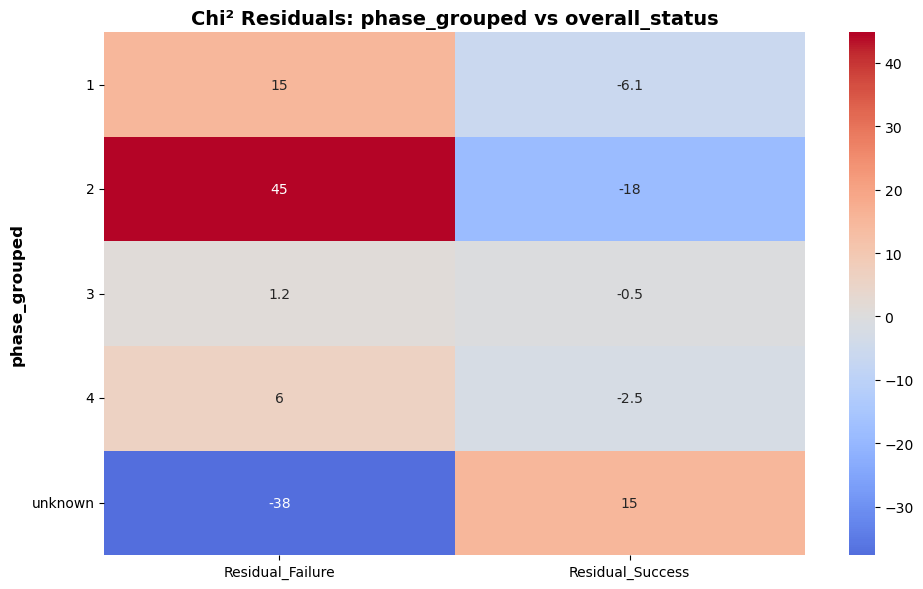

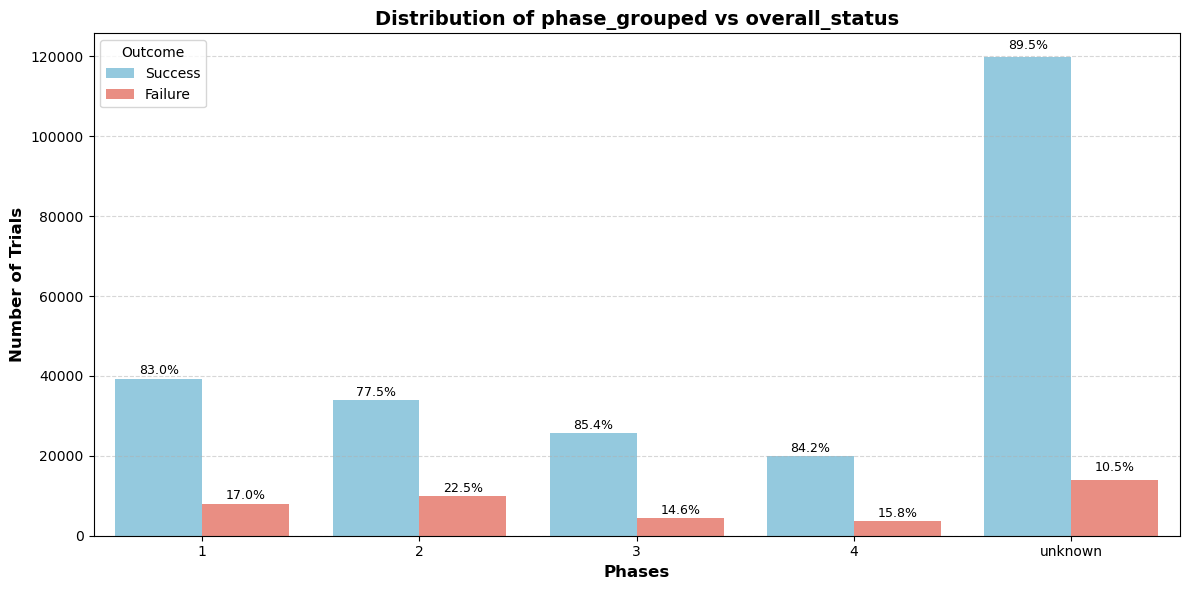

In [12]:
categorical_feature_stats(df_EDA_2, 'phase_grouped', expected_dict, xlabel = 'Phases', show=True)

intervention_grouped_vs_overall_status_summary:


,intervention_grouped,Failure,Success,Total,Success_rate,Failure_rate,Expected_Failure,Expected_Success,Residual_Failure,Residual_Success
0,Multiple,7115,29604,36719,80.62,19.38,5274.00,31445.00,25.35,-10.38
1,behavioral,1940,28662,30602,93.66,6.34,4395.41,26206.59,-37.04,15.17
2,biological,1544,9082,10626,85.47,14.53,1526.23,9099.77,0.45,-0.19
3,combination_product,124,658,782,84.14,15.86,112.32,669.68,1.10,-0.45
4,device,4529,23926,28455,84.08,15.92,4087.03,24367.97,6.91,-2.83
5,diagnostic_test,283,2032,2315,87.78,12.22,332.51,1982.49,-2.72,1.11
6,dietary_supplement,569,7850,8419,93.24,6.76,1209.23,7209.77,-18.41,7.54
7,drug,18706,88242,106948,82.51,17.49,15361.10,91586.90,26.99,-11.05
8,genetic,77,286,363,78.79,21.21,52.14,310.86,3.44,-1.41
9,other,2793,32714,35507,92.13,7.87,5099.92,30407.08,-32.30,13.23


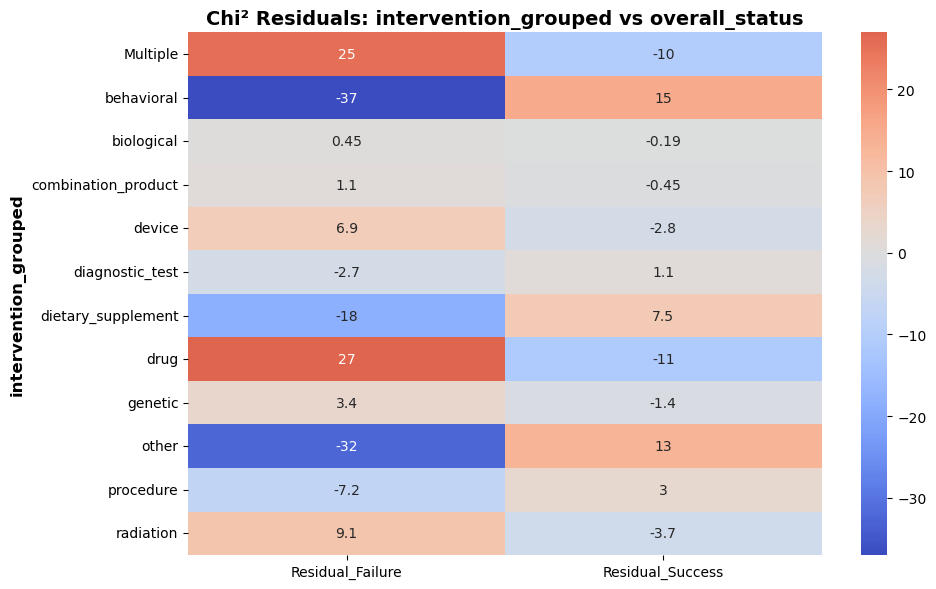

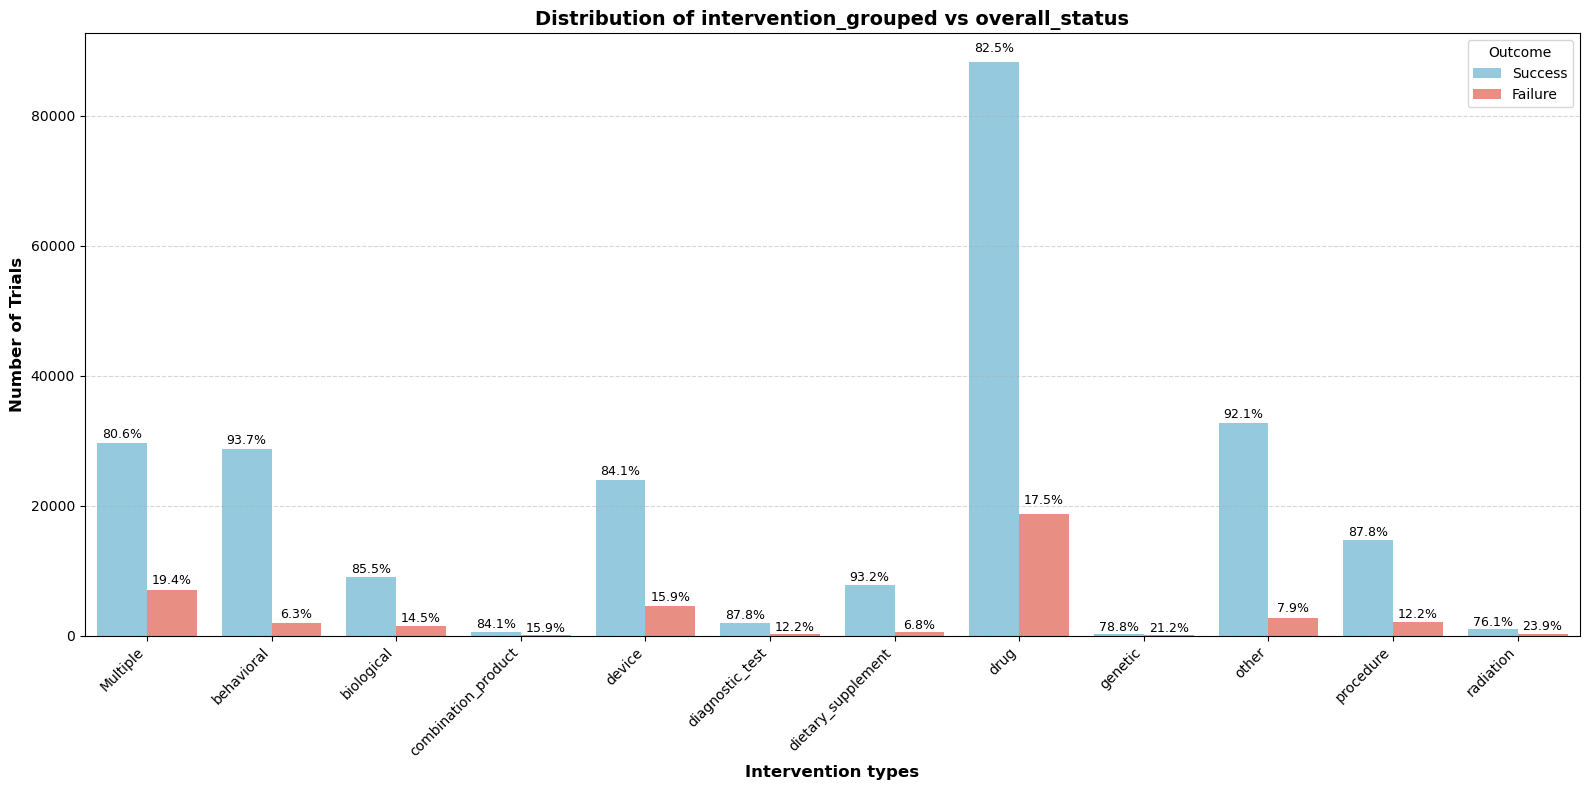

In [13]:
categorical_feature_stats(df_EDA_2, 'intervention_grouped', expected_dict, xlabel = 'Intervention types',
                          figsize = (16, 8), rotate_ticks = True, show=True)

condt_grouped_vs_overall_status_summary:


,condt_grouped,Failure,Success,Total,Success_rate,Failure_rate,Expected_Failure,Expected_Success,Residual_Failure,Residual_Success
0,Multiple,7121,42101,49222,85.53,14.47,7069.83,42152.17,0.61,-0.25
1,None,476,9335,9811,95.15,4.85,1409.17,8401.83,-24.86,10.18
2,cancers,9781,28798,38579,74.65,25.35,5541.16,33037.84,56.96,-23.33
3,cardiovascular_diseases,2159,11985,14144,84.74,15.26,2031.52,12112.48,2.83,-1.16
4,dental_disorders,100,2130,2230,95.52,4.48,320.30,1909.70,-12.31,5.04
5,dermatological_disorders,502,3719,4221,88.11,11.89,606.27,3614.73,-4.23,1.73
6,endocrine/metabolic_disorders,1280,12183,13463,90.49,9.51,1933.71,11529.29,-14.87,6.09
7,gastrointestinal_disorders,1342,6735,8077,83.38,16.62,1160.11,6916.89,5.34,-2.19
8,genetic_disorders,41,168,209,80.38,19.62,30.02,178.98,2.00,-0.82
9,infectious_diseases,1572,10146,11718,86.58,13.42,1683.07,10034.93,-2.71,1.11


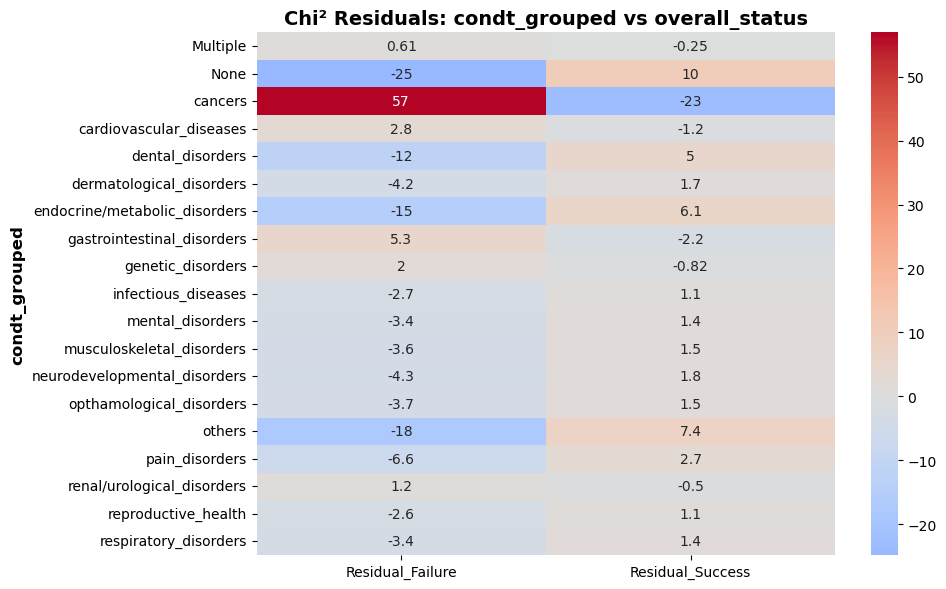

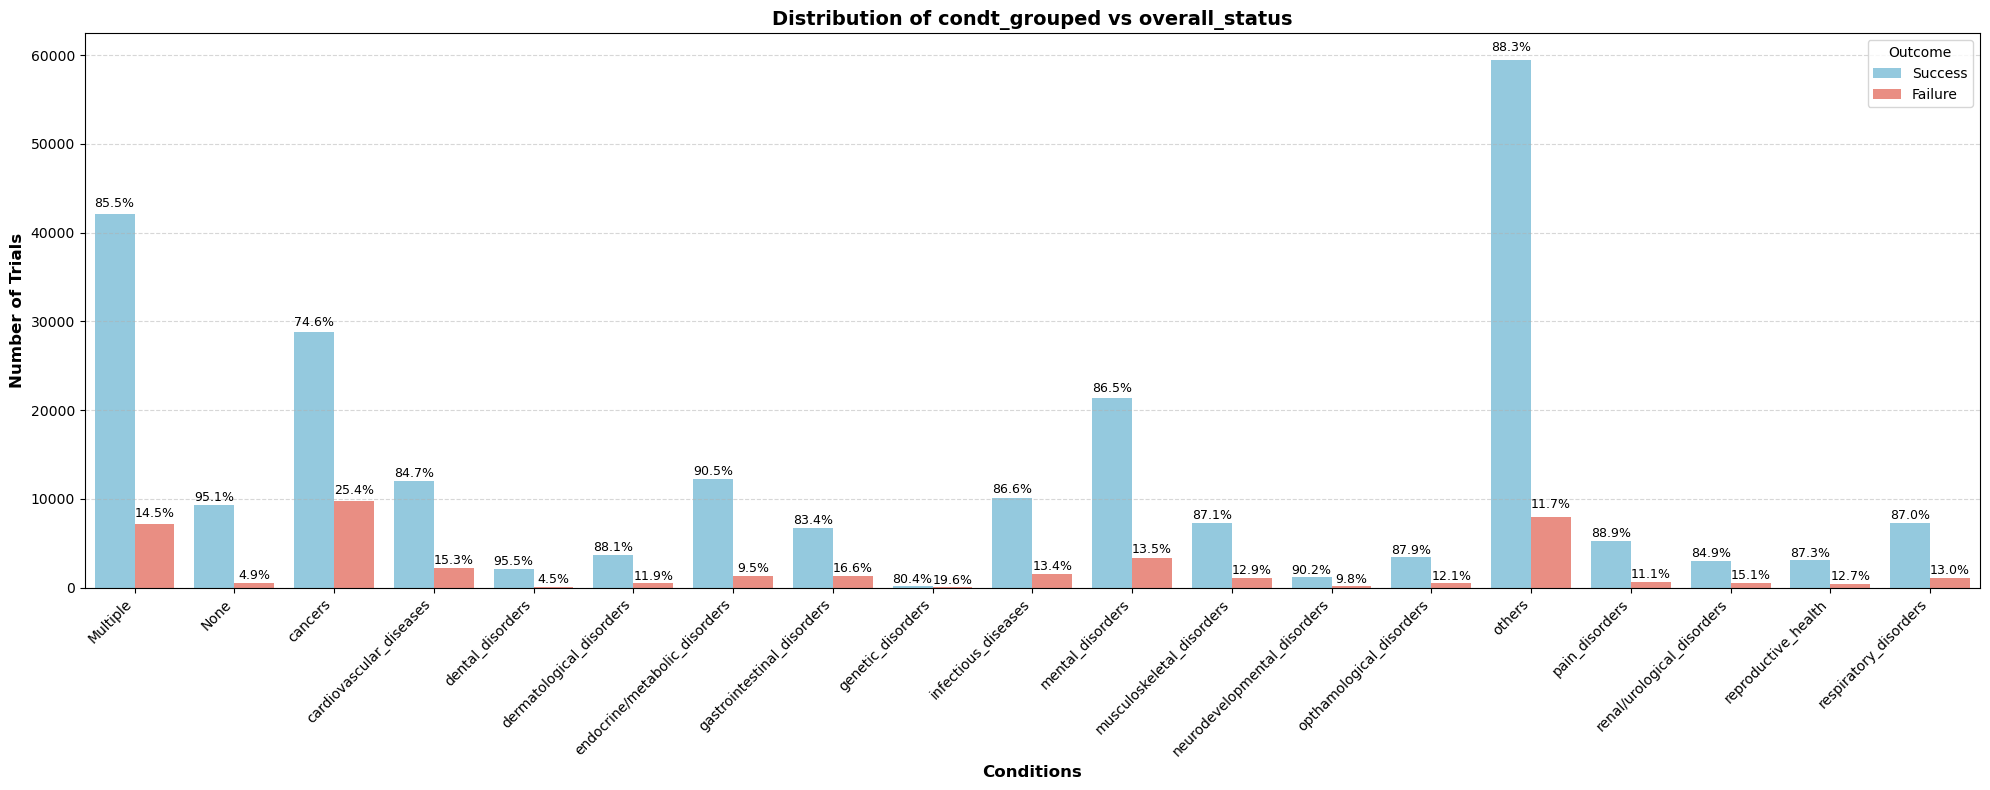

In [14]:
categorical_feature_stats(df_EDA_2, 'condt_grouped', expected_dict, xlabel = 'Conditions', 
                          figsize = (20, 8), rotate_ticks = True, show = True)

model_grouped_vs_overall_status_summary:


,model_grouped,Failure,Success,Total,Success_rate,Failure_rate,Expected_Failure,Expected_Success,Residual_Failure,Residual_Success
0,None,846,5076,5922,85.71,14.29,850.59,5071.41,-0.16,0.06
1,crossover,2067,24188,26255,92.13,7.87,3771.04,22483.96,-27.75,11.36
2,factorial,369,3634,4003,90.78,9.22,574.96,3428.04,-8.59,3.52
3,parallel,21699,142597,164296,86.79,13.21,23598.08,140697.92,-12.36,5.06
4,sequential,1540,5015,6555,76.51,23.49,941.50,5613.50,19.51,-7.99
5,single_group,13244,55222,68466,80.66,19.34,9833.87,58632.13,34.39,-14.08
6,unknown,274,2991,3265,91.61,8.39,468.96,2796.04,-9.00,3.69


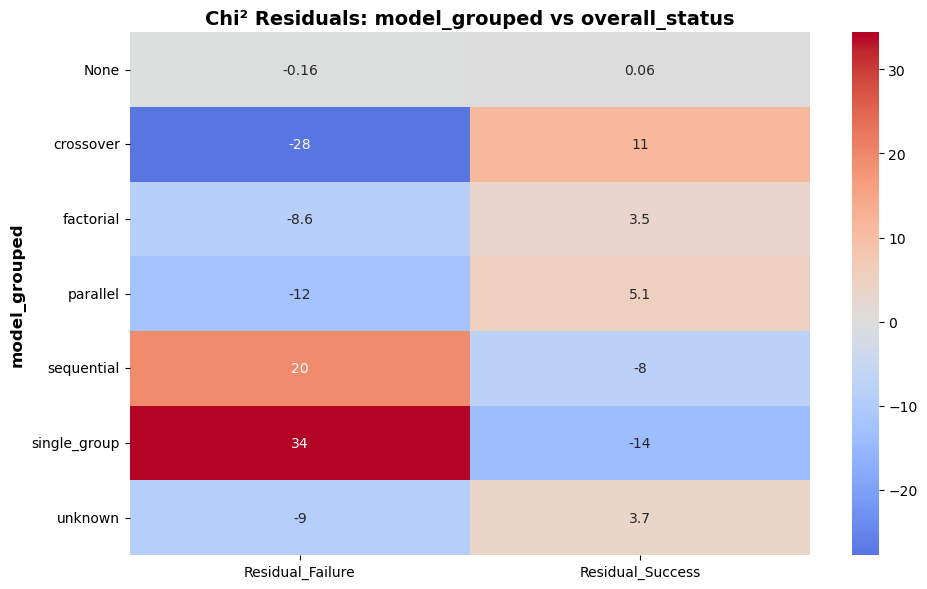

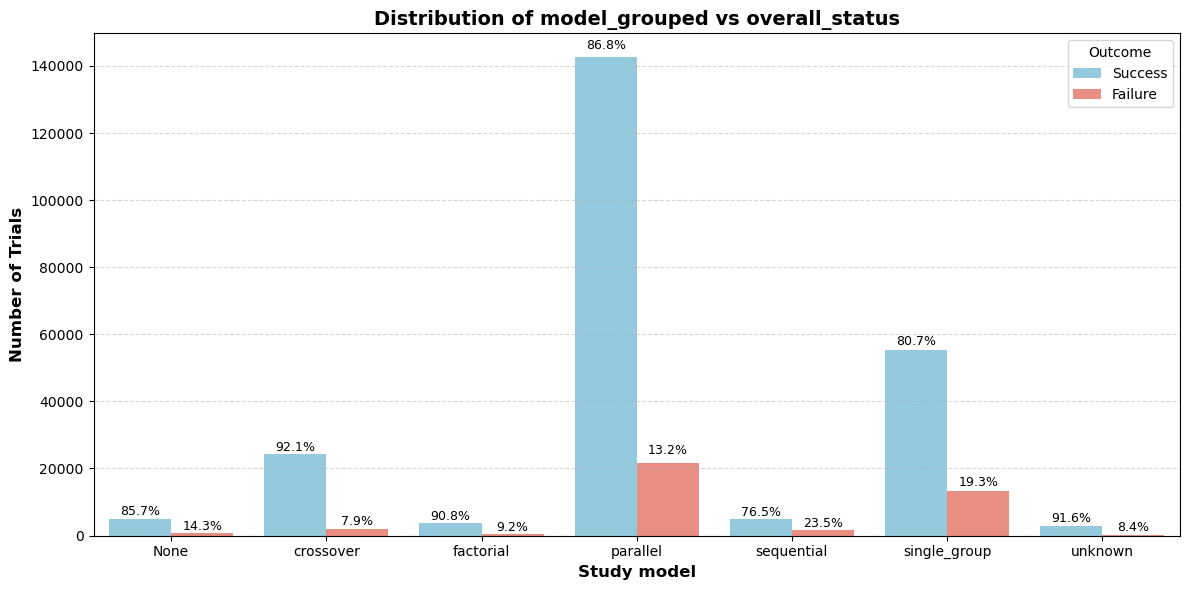

In [15]:
categorical_feature_stats(df_EDA_2, 'model_grouped', expected_dict, xlabel = 'Study model', show=True)

In [ ]:
# 어떤 변수가 모델의 중요한 피쳐가 될 것인가 선별하기 위해 
# expectid_dict활용해 이 변수가 결과와 상관이 없다면 나와야 할 기대치를 구하고 
# 실제 데이터와 비교하여 카이제곱 통계량을 산출함
categorical_feature_stats(df_EDA_2, 'allocation_grouped', expected_dict, xlabel = 'Allocation methods')
categorical_feature_stats(df_EDA_2, 'purpose_grouped', expected_dict, xlabel = 'Study purpose')
categorical_feature_stats(df_EDA_2, 'masking_grouped', expected_dict, xlabel = 'Masking methods')
categorical_feature_stats(df_EDA_2, 'sponsor_grouped', expected_dict, xlabel = 'Sponsor')
categorical_feature_stats(df_EDA_2, 'elig_age_grouped', expected_dict, xlabel = 'Age')
categorical_feature_stats(df_EDA_2, 'elig_gender_grouped', expected_dict, xlabel = 'Gender')

In [17]:
# Run chi-square summary on ternary/flag variables (-1, 0, 1)
flag_cols = ['has_dmc', 'has_expanded_access','is_fda_regulated_drug', 'is_fda_regulated_device', 'healthy_volunteers']
chi2_summary, expected_dict = chi2_analysis(df_EDA_2, flag_cols, filename='chi2_summary_flag_cols.csv')

Chi-square summary:


,Feature,Chi2,p_value,Cramers_v
0,has_dmc,1541.24,0.0,0.074
1,has_expanded_access,304.19,0.0,0.033
2,is_fda_regulated_drug,6199.71,0.0,0.149
3,is_fda_regulated_device,793.88,0.0,0.053
4,healthy_volunteers,4667.07,0.0,0.129


- has_dmc: Data Monitoring Committee, 독립적인 데이터 모니터링 위원회가 있는지 여부. dmc가 있다는 것은 대규모이거나 위험도가 높은 시험에서 안전성을 꼼꼼히 체크하고 있다는 신호
- has_expanded: "동정적 사용"이라고도 함. 허가전의 약물을 절박한 환자에게 예외적으로 제공하는 프로그램이 있는지 여부
- is_fda_regulated_drug/device: fda의 규제를 받는 약물이나 기기인지 확인. 규제 대상이라는 것은 그만큼 까다로운 기준을 통과해야 함 
- healty_volunteers: 건강한 피험자가 포함되는지 여부. 보통 임상1상(안전성테스트)에서 많이 나타나는 특징

- chi2(카이제곱 통계량): 값이 클수록 해당 변수가 성공/실패 여부와 강력하게 얽혀 있다는 뜻
- p_value(0.0): 변수들과 결과 사이의 관계가 단순한 우연일 확률이 0%에 가깝다는, 즉 통계적으로 매우 유의미함
- cramers_v(연관성크기): 0에서1사이값을 가지며, 값이 클수록 영향력이 큼.  

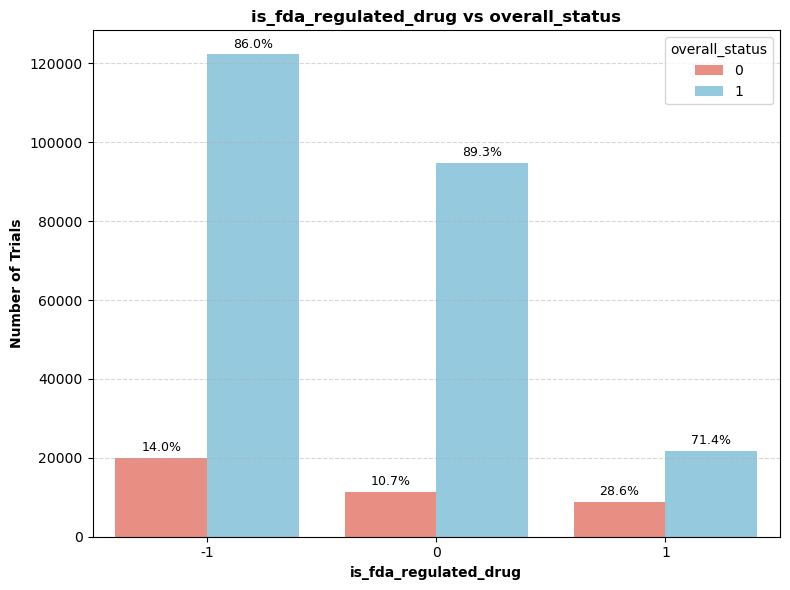

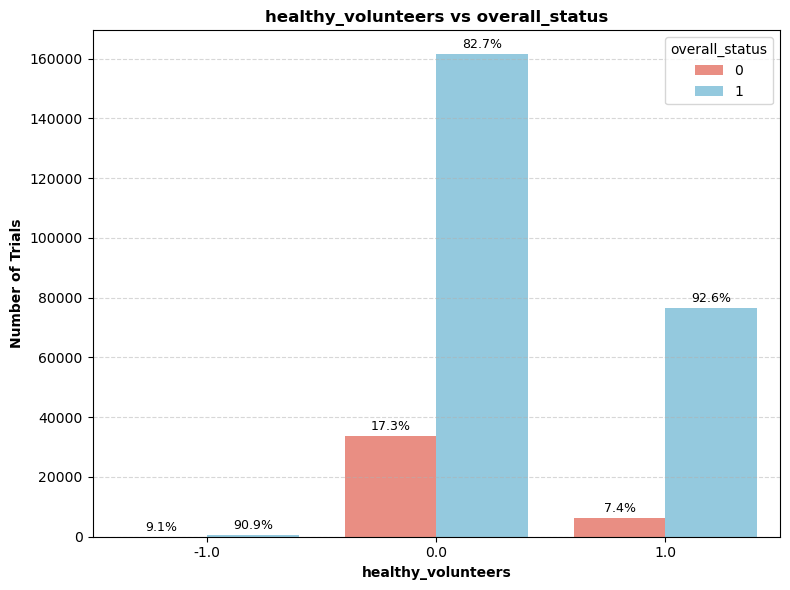

In [ ]:
# 실제 분포 확인
plot_flag_columns(df_EDA_2,'is_fda_regulated_drug', show=True)
plot_flag_columns(df_EDA_2, 'healthy_volunteers', show=True)

flag_cols = ['has_dmc', 'has_expanded_access', 'is_fda_regulated_device']
for col in flag_cols:
    plot_flag_columns(df_EDA_2, col)

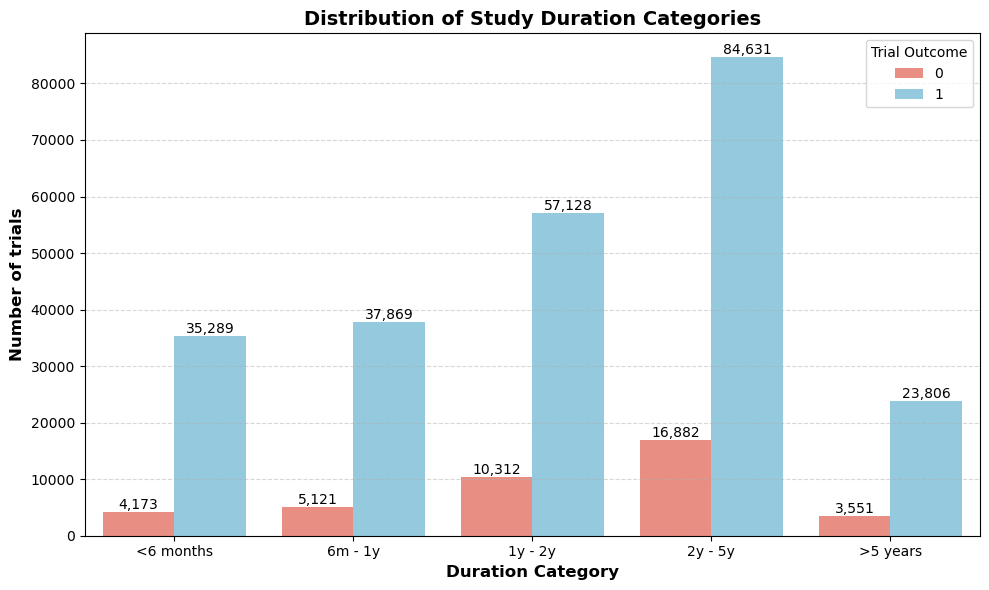

In [ ]:
# Categorize 'study durations' into bins and plot distribution vs trial outcomes
# 연구기간 변수에서 연속형 수치를 5개의 구간으로 나누고 (binning)
# 각 구간별로 성공(1)과 실패(0)가 어떻게 분포하는지 시각화
# Define bins (in days) and labels
bins = [-1, 180, 365, 730, 2000, float('inf')]  # 6개월, 1년, 2년, 약5.5년, float(int) 마지막 경계값을 무한대로
bin_labels = ['<6 months', '6m - 1y', '1y - 2y', '2y - 5y', '>5 years']

# Create duration bins
df_EDA_2['duration_bins'] = pd.cut(
    df_EDA_2['duration_of_study'],
    bins=bins,
    labels=bin_labels,
    right=False,    # 왼쪽 경계는 포함, 오른쪽 포함하지 않음
    include_lowest=True
)

# Custom colors (0 = Failure, 1 = Success)
custom_colors = {0: 'salmon', 1: 'skyblue'}

# Plot distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df_EDA_2, x='duration_bins', hue='overall_status',
    palette=custom_colors, legend=True
)

plt.title('Distribution of Study Duration Categories', fontsize=14, fontweight='bold')
plt.xlabel('Duration Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of trials', fontsize=12, fontweight='bold')
plt.grid(True, axis='y', linestyle="--", alpha=0.5)

# Annotate counts on bars
for p in ax.patches:
    count = int(p.get_height())
    if count > 0:
        ax.annotate(f'{count:,}',
                    (p.get_x() + p.get_width()/2, count),
                    ha='center', va='bottom', fontsize=10)

plt.legend(title='Trial Outcome')
savefig('study_duration_bins_dist.png')

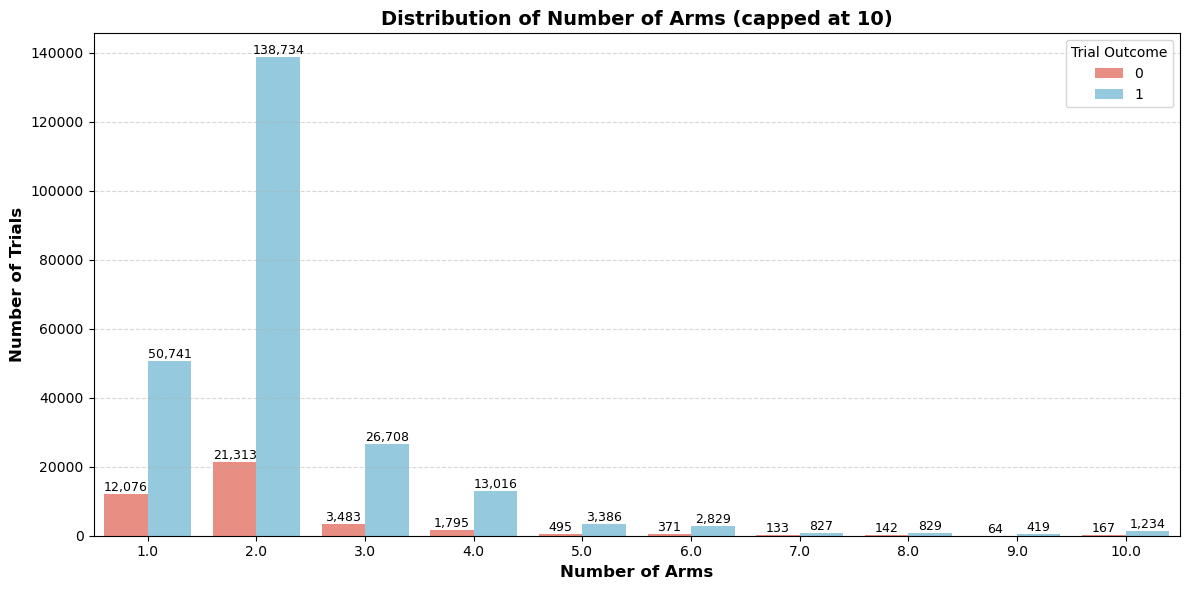

In [ ]:
# Cap 'number of arms' to a maximum of 10 and plot distribution vs trial outcomes
# 시험군/대조군의 수가 성공과 실패에 어떤 영향을 주는지 분석
# 10개 이상의 arm을 가진 모든 케이스 (이상치)는 하나의 카테고리로 capping 상한선 설정
# Cap the number of arms (values > 10 grouped into category "10")
df_EDA_2['arms_capped'] = df_EDA_2['number_of_arms'].apply(lambda x: x if x <= 10 else 10)

# Custom colors (0 = Failure, 1 = Success)
custom_colors = {0: 'salmon', 1: 'skyblue'}

# Plot distribution of arms_capped vs outcome
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_EDA_2, x='arms_capped', hue='overall_status',
    palette=custom_colors, legend=True
)

plt.title('Distribution of Number of Arms (capped at 10)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Arms', fontsize=12, fontweight='bold')
plt.ylabel('Number of Trials', fontsize=12, fontweight='bold')
plt.grid(True, axis='y', linestyle="--", alpha=0.5)

# Annotate counts on bars
for p in ax.patches:
    count = int(p.get_height())
    if count > 0:
        ax.annotate(f'{count:,}',
                    (p.get_x() + p.get_width()/2, count),
                    ha='center', va='bottom', fontsize=9)

plt.legend(title='Trial Outcome')
savefig("number_of_arms_dist.png")

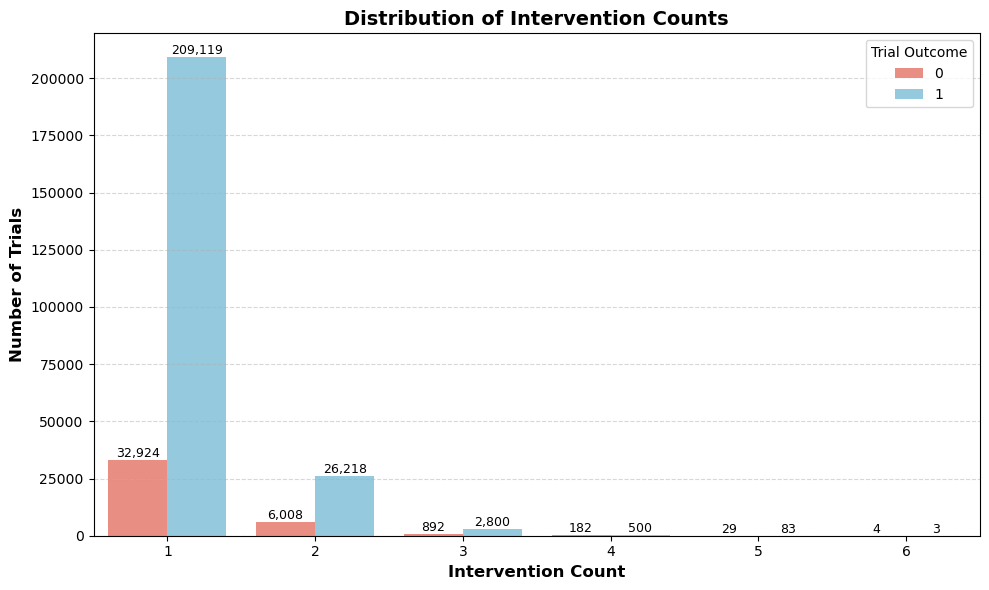

In [21]:
# Visualize trial completion status across 'intervention counts'
# 중재방식의 수 변수의 성공 실패 분포 확인
# Custom colors (0 = Failure, 1 = Success)
custom_colors = {0: 'salmon', 1: 'skyblue'}

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df_EDA_2, x='intervention_count', hue='overall_status',
    palette=custom_colors, legend=True
)

plt.title('Distribution of Intervention Counts', fontsize=14, fontweight='bold')
plt.xlabel('Intervention Count', fontsize=12, fontweight='bold')
plt.ylabel('Number of Trials', fontsize=12, fontweight='bold')
plt.grid(True, axis='y', linestyle="--", alpha=0.5)

# Annotate counts on bars
for p in ax.patches:
    count = int(p.get_height())
    if count > 0:
        ax.annotate(f'{count:,}',
                    (p.get_x() + p.get_width()/2, count),
                    ha='center', va='bottom', fontsize=9)

plt.legend(title='Trial Outcome')
savefig("intervention_counts_dist.png")

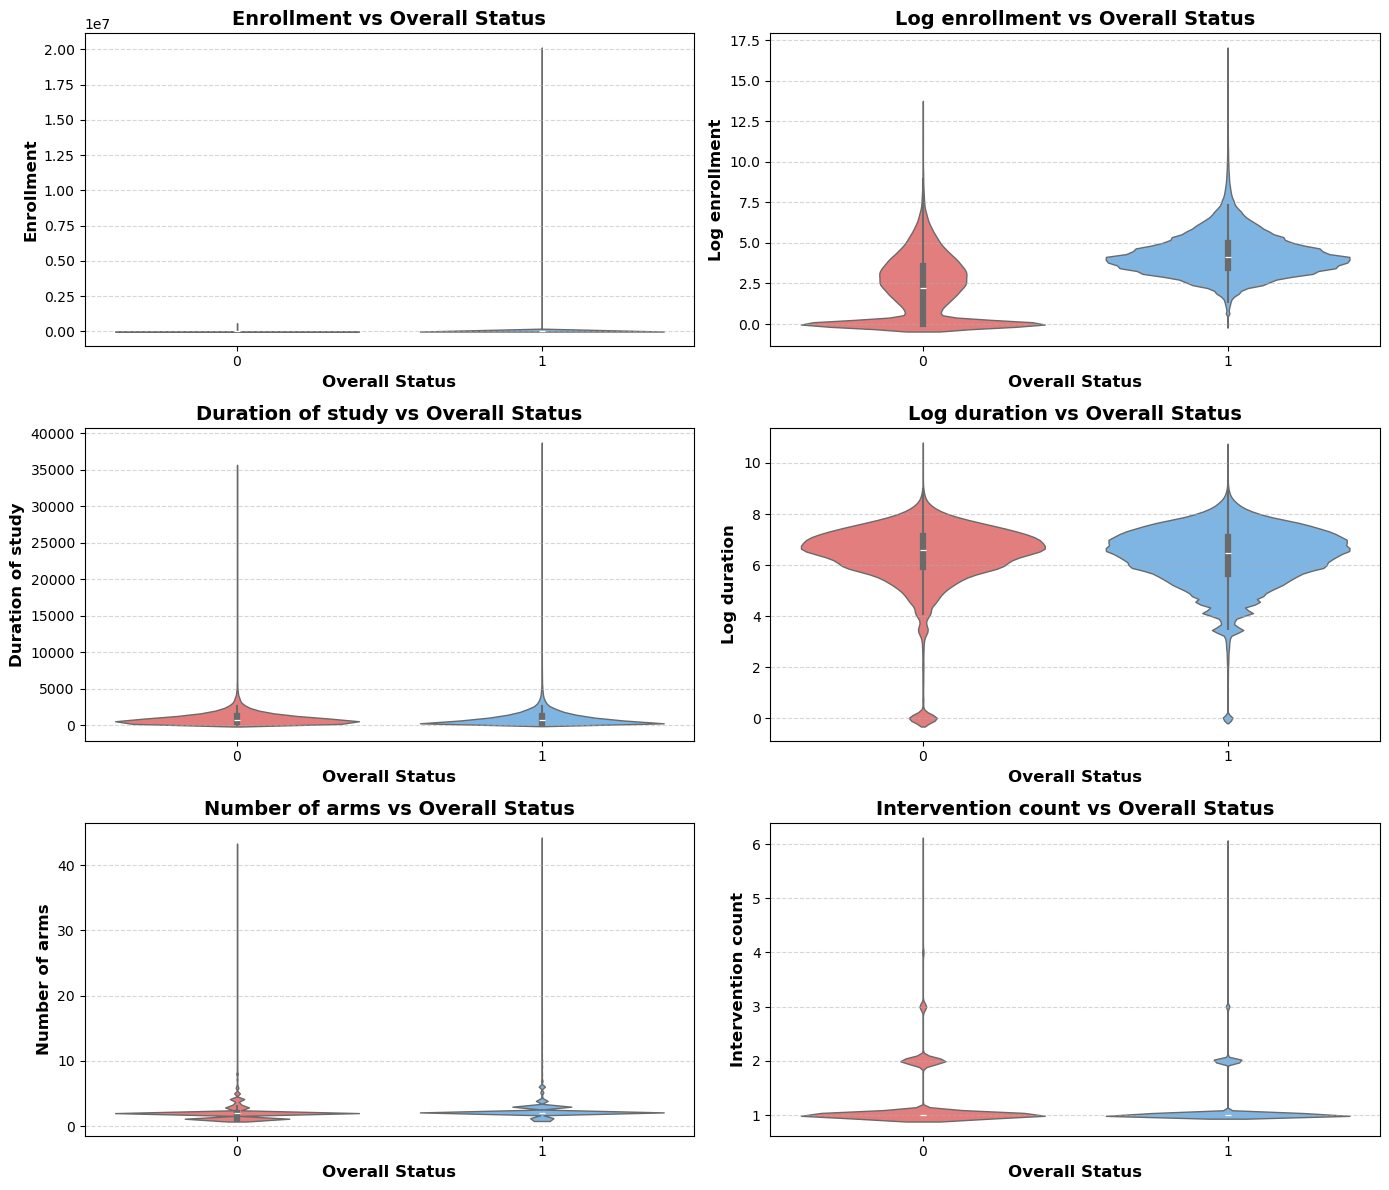

In [22]:
# violin plots for numerical columns vs trial 
# 수치형 데이터의 분포를 성공(1)과 실패(0) 그룹별로 비교하기 위해 바이올린 플롯 확인
# 바이올린 플롯은 박스플롯과 커널밀도추정(KDE)을 합친 형태로, 데이터의 사분위수 뿐만 아니라 값이 어디에 많이 몰려 있는지(밀도)까지 한눈에 

numerical_cols = [
    'enrollment', 'log_enrollment',
    'duration_of_study', 'log_duration',
    'number_of_arms', 'intervention_count'
]

# Create subplot grid (3 rows x 2 cols)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.violinplot(
        data=df_EDA_2, x='overall_status', y=col, hue='overall_status',
        palette={0: '#F46D6D', 1: '#6DB7F4'},
        inner='box', linewidth=1, legend=False, ax=axes[i]
    )
    axes[i].set_title(f"{col.replace('_', ' ').capitalize()} vs Overall Status",
                      fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Overall Status', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col.replace('_', ' ').capitalize(), fontsize=12, fontweight='bold')
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
savefig("num_cols_vs_overall.png", show=True)

In [23]:
# Mann-Whitney U test between numerical features and overall status
# Mann-Whitney U 통계 검증 
# 시각화로 보이는 차이가 우연일 확율은 얼마인가? 그리고 그 차이의 실제 크기는 어느정도인가? 
# 임상시험 데이터는 정규분포를 따르지 않고 한쪽으로 치우친 경우가 많기 때문에 비모수 검정 실시
# 만-휘트니 U검정: 데이터의 정규성을 가정하지 않고 순위 기분으로 비교하기 때문에 극단적인 이상치가 많은 현재 데이터셋에 가장 적합

results = []
for col in numerical_cols:
    # Split data by outcome
    # 성공과 실패 그룹으로 각각의 U통계량과 , p-value값 산출
    x = df_EDA_2.loc[df_EDA_2['overall_status'] == 0, col]  # 실패그룹
    y = df_EDA_2.loc[df_EDA_2['overall_status'] == 1, col]  # 성공그룹
    
    # Run Mann-Whitney U test
    U, p = mannwhitneyu(x, y, alternative='two-sided')

    n0, n1 = len(x), len(y)

    # Mean and standard deviation of U under null hypothesis
    # 귀무가설 하에서의 u 평균과 표준편차
    mean_u = n0 * n1 / 2
    std_u = np.sqrt(n0 * n1 * (n0 + n1 + 1) / 12)

    # Z-score and effect size (r)
    # 표준화 점수와 효과 크기(r) 계산
    # 데이터 개수가 많으면 (현재 수십만건) 아주 미세한 차이도 p-value는 무조건 0(유의미함)으로 나옴
    # 이때 r값을 보면 실제로 모델 예측에 도움이 될 만큼 큰 차이인가를 판단할 수 있음
    # 보통 0.1 이상이면 작은효과, 0.3이면 중간, 0.5이상이면 큰 효과
    z_score = (U - mean_u) / std_u
    r = abs(z_score) / np.sqrt(n0 + n1)

    # Collect results
    results.append({
        'Feature': col,
        'Failure_total': n0,
        'Success_total': n1,
        'Failure_median': np.median(x).round(2),
        'Success_median': np.median(y).round(2),
        'IQR_failure': (np.percentile(x, 75) - np.percentile(x, 25)).round(2),
        'IQR_success': (np.percentile(y, 75) - np.percentile(y, 25)).round(2),
        'U_stat': f'{U:.2e}',
        'p_value': f'{p:.2g}',
        'effect_size_r': round(r, 3)
    })

# Create summary DataFrame
mw_summary = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)

# Save summary CSV
file_path = RESULTS_DIR / "num_cols_mw_summary.csv"
mw_summary.to_csv(file_path, index=False)

print("\nMann-Whitney U test summary between numerical features and overall status:")
display(mw_summary)


Mann-Whitney U test summary between numerical features and overall status:


,Feature,Failure_total,Success_total,Failure_median,Success_median,IQR_failure,IQR_success,U_stat,p_value,effect_size_r
0,enrollment,40039,238723,8.00,60.00,35.00,115.00,1.86e+09,0,0.371
1,log_enrollment,40039,238723,2.20,4.11,3.58,1.55,1.86e+09,0,0.371
2,number_of_arms,40039,238723,2.00,2.00,1.00,0.00,4.29e+09,1.7e-291,0.062
3,intervention_count,40039,238723,1.00,1.00,0.00,0.00,5.04e+09,5.1e-196,0.033
4,duration_of_study,40039,238723,730.00,639.00,883.00,941.00,5.09e+09,8.8e-95,0.039
5,log_duration,40039,238723,6.59,6.46,1.23,1.45,5.09e+09,8.8e-95,0.039


In [24]:
# 성공/실패(종속변수) 관계를 넘어, 독립변수끼리 서로 얼마나 얽혀 있는지 파악
# 범주형 변수에 따라 수치형 변수의 분포가 유의미하게 달라지는지 확인하는 크루스칼-발리스 검정 수행
# 비모수 ANOVA: 세 개 이상의 집단(예: 임상 1상, 2상, 3상) 간에 수치형 데이터(예: 피험자 수)의 차이가 있는지 볼 때 사용
# 정규분포를 가정하지 않으므로, 임상 데이터처럼 이상치가 많고 치우친 데이터에 가장 적합한 검정 방법
# Kruskal–Wallis H-test between categorical and numerical features
# Define categorical and numerical features
cat_cols = [
    'phase_grouped', 'intervention_grouped', 'condt_grouped',
    'allocation_grouped', 'masking_grouped', 'model_grouped',
    'purpose_grouped', 'sponsor_grouped', 'elig_age_grouped', 'elig_gender_grouped'
]
num_cols = ['enrollment', 'duration_of_study', 'number_of_arms', 'intervention_count']

results = []

# Loop through categorical × numerical pairs
for cat in cat_cols:
    for num in num_cols:
        data = df_EDA_2[[cat, num]].dropna()

        # Split numerical values by each category level
        groups = [data.loc[data[cat] == level, num] for level in data[cat].unique()]

        # Run Kruskal–Wallis H-test
        H, p = kruskal(*groups)

        N = len(data)                # total samples
        k = data[cat].nunique()      # number of groups

        # Effect size: epsilon-squared 에실론 제곱 
        # p-value는 샘플수가 많으면 무조건 0으로 나옴. 
        # 실질적인 상관관계의 강도를 측정하기 위해 에실론 제곱 계산
        epsilon_sq = (H - k + 1) / (N - k) if N > k else None

        results.append({
            'Categorical_col': cat,
            'Numerical_col': num,
            'Kruskal_H': round(H, 2),
            'p_value': f'{p:.2g}',
            'epsilon_sq': round(epsilon_sq, 3) if epsilon_sq is not None else None
        })

# Create summary DataFrame
results_df = pd.DataFrame(results).sort_values('epsilon_sq', ascending=False).reset_index(drop=True)

# Save results to processed data folder
file_path = RESULTS_DIR / "Kruskal_num_cat_summary.csv"
results_df.to_csv(file_path, index=False)

print("\nKruskal–Wallis H-test summary between categorical and numerical features:")
results_df.head(10)


Kruskal–Wallis H-test summary between categorical and numerical features:


,Categorical_col,Numerical_col,Kruskal_H,p_value,epsilon_sq
0,intervention_grouped,intervention_count,278162.58,0,0.998
1,model_grouped,number_of_arms,147927.90,0,0.531
2,allocation_grouped,number_of_arms,99215.56,0,0.356
3,masking_grouped,number_of_arms,46691.62,0,0.167
4,model_grouped,enrollment,41003.55,0,0.147
5,condt_grouped,duration_of_study,39380.89,0,0.141
6,phase_grouped,enrollment,36223.86,0,0.130
7,allocation_grouped,enrollment,26248.90,0,0.094
8,sponsor_grouped,duration_of_study,14898.78,0,0.053
9,model_grouped,duration_of_study,13751.50,0,0.049


In [25]:
# Export dataset for EDA Part 3
df_EDA_2.to_csv(DATA_PROCESSED / "df_EDA_2.csv", index=False)